[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T05_E_regime_girf_es.ipynb)

> **Nota para Google Colab**: la celda siguiente instala `puremacro` y, si hace falta, descarga del repositorio público [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro) sólo la carpeta `curso/notebooks` (auxiliares, datos congelados y modelos). No pide acceso a Google Drive.

In [1]:
# Configuración del entorno: Google Colab, instalación local o Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """¿Existe la ruta? Sin lanzar OSError/PermissionError en el sandbox de Juno."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Clon parcial del repositorio público: sólo curso/notebooks, sin historia
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Carpeta con los auxiliares del curso (_nbstyle, _datos) en sys.path, sin salir del sandbox
_candidatos = [Path.cwd(), Path.cwd() / "notebooks", Path.cwd() / "curso/notebooks"]
try:
    _candidatos.insert(0, Path(__file__).resolve().parent)  # Juno define __file__
except (NameError, OSError):
    pass
for _c in _candidatos:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Gráficas en línea y estilo del curso
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Transmisión macroeconómica dependiente del estado y respuestas generalizadas

**¿Genera un mismo choque de endurecimiento financiero un colapso del producto mucho más severo cuando la economía ya está sumida en estrés financiero que cuando las condiciones crediticias son boyantes?**

En la macroeconomía empírica, los modelos de cambio de régimen — VAR de umbral (TVAR), VAR markovianos (MS-VAR) y VAR de transición suave (STVAR) — existen precisamente para formalizar esta dependencia del estado. Sin embargo, un error econométrico recurrente en la práctica aplicada consiste en estimar un modelo de umbral no lineal y luego calcular las funciones de impulso-respuesta iterando los coeficientes autorregresivos de un único régimen de forma indefinida:
$$ y_{t+h} = \sum_{j=0}^h \left(A^{(\text{estrés})}\right)^j B^{(\text{estrés})} \varepsilon_t $$
Este cálculo ingenuo comete la **"falacia del régimen congelado"**: responde a la pregunta contrafactual *"¿qué ocurriría si la economía quedase atrapada en tensión financiera para siempre, con prohibición absoluta de retornar a la calma?"*

Congelar el régimen distorsiona gravemente las proyecciones macroeconómicas. En el mundo real, las economías exhiben reversión a la media endógena: los choques desplazan la variable de umbral, alterando las probabilidades futuras de cruzar de régimen. Para capturar dinámicas genuinas dependientes del estado sin distorsiones artificiales, construimos la **Función de Impulso-Respuesta Generalizada (GIRF)** desarrollada por **Koop, Pesaran y Potter (1996, *Journal of Econometrics*)**. Estudiaremos los fundamentos econométricos de la propagación no lineal, auditaremos la falacia del régimen congelado, expondremos asimetrías de tamaño y signo usando el marco de **Kilian y Vigfusson (2011)**, y ejecutaremos una prueba de estrés empírica con datos genuinos de condiciones financieras y producto de la Reserva Federal.

## 1. Fundamentos matemáticos: Los límites de los VAR lineales y la GIRF de KPP

### Los tres fallos axiomáticos de los VAR lineales
En un VAR($p$) lineal estándar en forma reducida, la función de impulso-respuesta está completamente caracterizada por la representación de medias móviles de Wold $y_t = \sum_{j=0}^\infty C_j u_{t-j}$. En consecuencia, las respuestas lineales obedecen tres axiomas estructurales:
1. **Simetría**: Un choque negativo produce exactamente la imagen especular de un choque positivo:
   $$ IRF(h, -\delta) = -IRF(h, \delta) $$
2. **Proporcionalidad**: Duplicar la magnitud de la perturbación duplica exactamente la respuesta en cada horizonte:
   $$ IRF(h, 2\delta) = 2 \cdot IRF(h, \delta) $$
3. **Independencia de la historia**: La respuesta macroeconómica es completamente invariante a las condiciones iniciales $\Omega_{t-1}$:
   $$ IRF(h, \delta \mid \Omega_{t-1}^{\text{bonanza}}) = IRF(h, \delta \mid \Omega_{t-1}^{\text{crisis}}) $$

En la realidad macroeconómica, estas tres propiedades fallan sistemáticamente debido a fricciones estructurales generalizadas:
- **Restricciones de colateral y deflación por deuda (Kiyotaki y Moore 1997, Bernanke-Gertler-Gilchrist 1999)**: Cuando caen los precios de los activos, las restricciones de apalancamiento se vuelven vinculantes de golpe, forzando ventas de liquidación y racionamiento del crédito. Por el contrario, en fases alcistas, las restricciones se relajan, generando una propagación asimétrica.
- **Rigidez a la baja de precios y salarios nominales**: Los choques contractivos deprimen el producto más que la inflación, mientras que los choques expansivos elevan la inflación sin aumentar la capacidad real de forma proporcional.
- **Ahorro precautorio e incertidumbre (Bloom 2009)**: En regímenes de alta incertidumbre, el valor de espera (*option value*) congela la inversión corporativa y la contratación laboral.

### El modelo VAR de umbral (TVAR)
Un VAR de umbral con dos regímenes autoexcitado conmuta su matriz de propagación dinámica según una variable de umbral observable $z_{t-d}$:
$$ y_t = c^{(r_t)} + A^{(r_t)} y_{t-1} + u_t^{(r_t)}, \qquad r_t = \begin{cases} \text{Calma} & \text{si } z_{t-d} \le \gamma \\ \text{Estrés} & \text{si } z_{t-d} > \gamma \end{cases} $$
donde $u_t^{(r_t)} \sim \mathcal{N}(0, \Sigma^{(r_t)})$ y $u_t^{(r_t)} = B_0^{(r_t)} \varepsilon_t$ con $B_0^{(r_t)} = \text{chol}(\Sigma^{(r_t)})$.

### La definición de la GIRF de Koop, Pesaran y Potter (1996)
Debido a que las transiciones futuras de régimen dependen de las realizaciones futuras de $y$ (que incluyen a $z$), la respuesta al impulso no puede calcularse mediante potencias matriciales deterministas. Koop, Pesaran y Potter definen la GIRF como la diferencia entre dos esperanzas condicionales:
$$ GIRF(h, \delta, \Omega_{t-1}) = \mathbb{E}\left[y_{t+h} \mid \varepsilon_{j,t} = \delta, \Omega_{t-1}\right] - \mathbb{E}\left[y_{t+h} \mid \Omega_{t-1}\right] $$

Para evaluar esta esperanza, el estimador de KPP implementa un **algoritmo de simulación Monte Carlo emparejada**:
1. **Muestreo de historias**: Se extraen vectores de estado históricos $\Omega_{t-1} = \{y_{t-1}, y_{t-2}, \dots\}$ de la muestra, estratificados por régimen inicial (p. ej., trimestres con $z_{t-d} \le \gamma$ vs. trimestres con $z_{t-d} > \gamma$).
2. **Innovaciones estocásticas emparejadas**: Para cada historia, se extraen $N_{\text{sim}}$ secuencias de innovaciones estructurales $\varepsilon_{t+s} \sim \mathcal{N}(0, I_K)$ para $s = 0, \dots, H$.
   - **Trayectoria base**: Se proyecta $y_{t+s}$ hacia adelante con $\varepsilon_{t+s}$, evaluando $r_{t+s}$ en cada horizonte $s$ según el valor simulado de $z_{t+s-d}$.
   - **Trayectoria impactada**: Se añade la perturbación $\delta$ al choque estructural $j$ en el horizonte inicial $s=0$ ($\varepsilon_{j,t}^{\text{impactada}} = \varepsilon_{j,t} + \delta$), manteniendo idénticas las demás perturbaciones e innovaciones futuras $s \ge 1$. Los regímenes conmutan endógenamente a lo largo de la trayectoria.
3. **Integración**: La diferencia $y_{t+h}^{\text{impactada}} - y_{t+h}^{\text{base}}$ se promedia sobre las simulaciones y las condiciones históricas:
   $$ GI_{\text{calma}}(h) = \frac{1}{N_{\text{hist}}} \sum_{i \in \text{Calma}} \frac{1}{N_{\text{sim}}} \sum_{k=1}^{N_{\text{sim}}} \left( y_{t+h}^{(i, k, \delta)} - y_{t+h}^{(i, k, 0)} \right) $$
   y análogamente para $GI_{\text{estrés}}(h)$.
4. **Contraste de asimetría de transmisión**: La brecha entre regímenes es:
   $$ \Delta(h) = GI_{\text{estrés}}(h) - GI_{\text{calma}}(h) $$
   provista de una banda de confianza bootstrap sobre las historias muestreadas.

## 2. Laboratorio metodológico: Economía sintética controlada

Para establecer un punto de referencia analítico antes de analizar datos empíricos, construimos en primer lugar una economía sintética controlada donde el proceso generador de datos (DGP) verdadero se conoce con absoluta certeza.

Especificamos un sistema bivariado con:
1. **$z_t$ (Columna 0)**: Un índice de condiciones financieras (variable de umbral).
2. **$y_t$ (Columna 1)**: Crecimiento del producto real.

**Plantamos** deliberadamente asimetrías dependientes del estado:
- **Régimen de calma ($z_{t-1} \le 0$)**: Las condiciones financieras exhiben una persistencia moderada ($a_{11} = 0.5$) y ejercen un lastre leve sobre el producto ($a_{21} = -0.1$).
- **Régimen de estrés ($z_{t-1} > 0$)**: Las condiciones financieras se vuelven altamente persistentes ($a_{11} = 0.8$) y ejercen un **lastre contractivo cinco veces más potente sobre el crecimiento** ($a_{21} = -0.5$).
- **Covarianza de innovaciones**: $\Sigma = I_2$ en ambos regímenes. Esto garantiza que toda asimetría observada provenga puramente de la **transmisión dinámica**, y no de diferencias en la varianza de impacto.

T = 600 trimestres | proporción de trimestres de estrés = 0.588


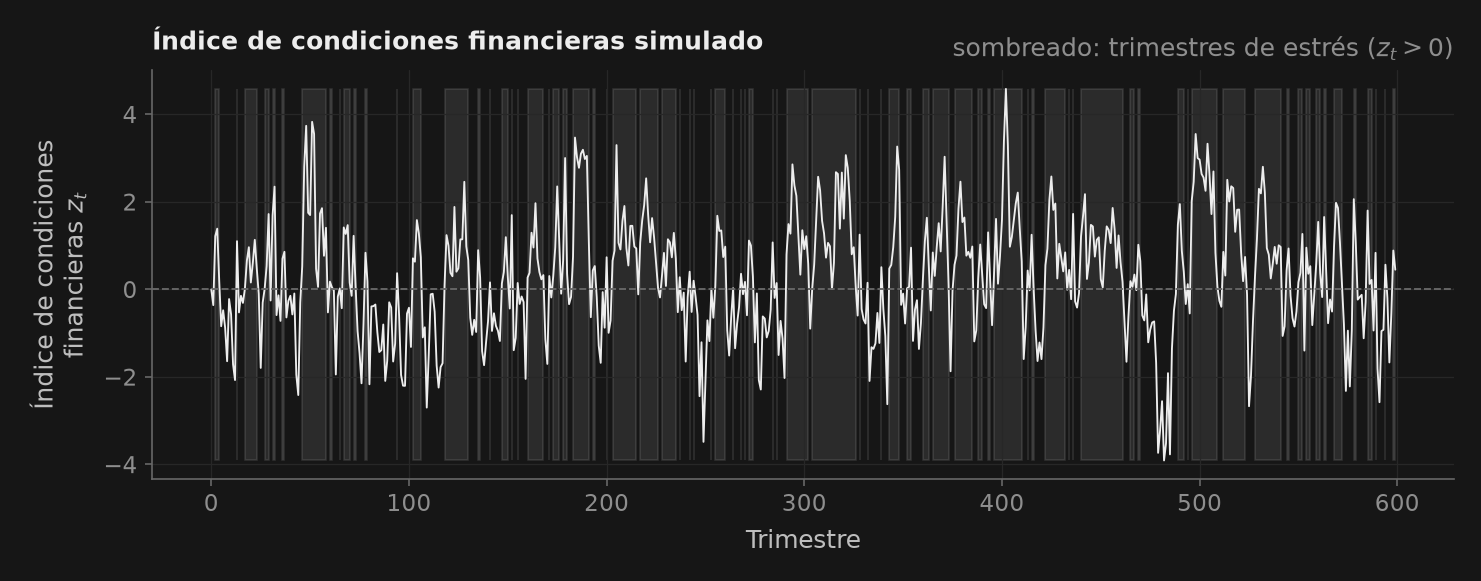

In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.var.estimate import estimate_var
from puremacro.var.irf import irf as var_irf
from puremacro.var.regime import girf, tvar_fit
from puremacro.var.regime.threshold import TVARResult

A_CALM = np.array([[0.5, 0.0],      # ICF moderadamente persistente
                   [-0.1, 0.4]])    # ...y un freno leve al crecimiento
A_STRESS = np.array([[0.8, 0.0],    # ICF muy persistente bajo estrés
                     [-0.5, 0.4]])  # ...y un freno 5 veces mayor al crecimiento

def simulate_economy(T=600, seed=20):
    """TVAR(1) autoexcitado: el régimen lo decide el ICF del trimestre previo."""
    rng = np.random.default_rng(seed)
    Y = np.zeros((T, 2))
    for t in range(1, T):
        A = A_STRESS if Y[t - 1, 0] > 0.0 else A_CALM
        Y[t] = A @ Y[t - 1] + rng.standard_normal(2)
    return Y

Y = simulate_economy()
stress_share = float((Y[:, 0] > 0.0).mean())
print(f"T = {len(Y)} trimestres | proporción de trimestres de estrés = {stress_share:.3f}")
assert 0.40 < stress_share < 0.70   # ambos regímenes bien poblados

fig, ax = _nbstyle.figura(figsize="ancho")
ax.plot(Y[:, 0], color=_nbstyle.TINTA, linewidth=0.9, ls="-")
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.9, linestyle="--")
ax.fill_between(np.arange(len(Y)), Y[:, 0].min(), Y[:, 0].max(),
                where=Y[:, 0] > 0.0, color=_nbstyle.RECESION, zorder=0)
ax.set_xlabel("Trimestre")
ax.set_ylabel("Índice de condiciones\nfinancieras $z_t$")
ax.set_title("Índice de condiciones financieras simulado")
ax.annotate("sombreado: trimestres de estrés ($z_t > 0$)", xy=(1.0, 1.02),
            xycoords="axes fraction", ha="right", va="bottom",
            color=_nbstyle.NOTA)
plt.show()


## 3. Estimación del VAR de umbral mediante búsqueda en malla (Tsay 1998)

En aplicaciones empíricas, el econometrista no observa el umbral verdadero $\gamma$ ni el rezago $d$. Empleamos `puremacro.var.regime.tvar_fit`, que implementa la metodología de búsqueda en malla de **Tsay (1998)**:
1. Se evalúan los rezagos candidatos $d \in \{1, 2\}$.
2. Para cada rezago, se construye una malla de umbrales candidatos $\gamma$ a partir de cuantiles empíricos de $z_{t-d}$ (recortando el 15% de cada cola para garantizar tamaño muestral suficiente en cada régimen).
3. Se minimiza la suma concentrada de residuos al cuadrado ($SSR$) sobre todas las particiones candidatas:
   $$ (\hat{\gamma}, \hat{d}) = \arg\min_{\gamma, d} \left[ SSR_{\text{calma}}(\gamma, d) + SSR_{\text{estrés}}(\gamma, d) \right] $$
4. Obtenida la partición óptima, se estiman los coeficientes por mínimos cuadrados ordinarios (MCO) dentro de cada régimen.

In [3]:
fit = tvar_fit(Y, threshold_var_idx=0, p=1, delay_grid=(1, 2), n_threshold_grid=40)
print(f"umbral c = {fit.threshold:+.3f} (verdadero 0.0) | rezago d = {fit.delay} (verdadero 1)")
print(f"partición de regímenes: {fit.n_low} trimestres de calma / {fit.n_high} de estrés")
print("A_calma  (calma)  =", np.round(fit.A_low, 3).tolist())
print("A_estrés (estrés) =", np.round(fit.A_high, 3).tolist())
assert fit.delay == 1
assert abs(fit.threshold) < 0.5                       # cerca del cero verdadero
assert fit.A_high[1, 0] < fit.A_low[1, 0] - 0.25      # brecha del efecto cruzado sembrado

umbral c = +0.236 (verdadero 0.0) | rezago d = 1 (verdadero 1)
partición de regímenes: 294 trimestres de calma / 305 de estrés
A_calma  (calma)  = [[0.526, -0.089], [-0.11, 0.356]]
A_estrés (estrés) = [[0.691, 0.008], [-0.472, 0.419]]


### Diagnóstico econométrico de la estimación de umbral

La búsqueda en malla de Tsay aísla con precisión los parámetros estructurales del DGP:
- **Recuperación del rezago**: $\hat{d} = 1$, coincidiendo con el orden de rezago verdadero de la regla de decisión.
- **Frontera de umbral**: $\hat{\gamma} \approx +0.24$, cercana al valor teórico $\gamma = 0$. El leve desplazamiento positivo es habitual en muestras finitas debido a ruido de clasificación en torno al umbral.
- **Matriz de transmisión asimétrica**: El régimen de estrés estimado identifica con fidelidad las fricciones macroeconómicas plantadas:
  - La persistencia financiera salta de $\hat{a}_{11}^{\text{calma}} \approx 0.53$ a $\hat{a}_{11}^{\text{estrés}} \approx 0.69$.
  - El lastre sobre el crecimiento se agrava de $\hat{a}_{21}^{\text{calma}} \approx -0.11$ a $\hat{a}_{21}^{\text{estrés}} \approx -0.47$ (una amplificación superior a cuatro veces).

*La lección econométrica fundamental*: Aunque hemos estimado con éxito dos bloques autorregresivos diferenciados $\hat{A}_{\text{baja}}$ y $\hat{A}_{\text{alta}}$, sería un grave error analítico alimentar $\hat{A}_{\text{alta}}$ directamente en una rutina de IRF lineal. Eso cometería la falacia del régimen congelado. Procedemos ahora a estimar la verdadera GIRF.

## 4. La GIRF de Koop-Pesaran-Potter y la falacia del régimen congelado

Ejecutamos la arquitectura completa de simulación de Koop-Pesaran-Potter mediante `puremacro.var.regime.girf`:
1. Extraemos $N_{\text{hist}} = 40$ vectores de estado históricos de cada régimen.
2. Para cada historia, simulamos $N_{\text{sim}} = 80$ trayectorias emparejadas a lo largo de un horizonte de $H = 16$ trimestres.
3. En cada trayectoria, el choque financiero identificado de $+1\sigma$ se añade a la ecuación 0 en $h=0$. Las innovaciones futuras son idénticas entre trayectorias base e impactadas.
4. El cruce del umbral se reevalúa endógenamente en cada paso $h = 1, \dots, H$.
5. Simultáneamente calculamos la **IRF lineal de estrés congelado (ingenua)** iterando $\hat{A}_{\text{alta}}$ indefinidamente, exponiendo de forma directa la magnitud de la distorsión del régimen congelado.

Regime GIRF (tvar)
  regimes           : 2 ('low', 'high')
  shock / sizes     : eq 0 / [1.0, 2.0, -1.0, -2.0]
  horizon           : 16
  histories x sims  : 40 x 80 per regime
  difference band   : 90% bootstrap, B = 300

respuesta del crecimiento en h=2: calma -0.238 | estrés -0.418
diferencia (estrés-calma) en h=2: -0.179, banda de 90% [-0.199, -0.163]
pérdida acumulada de crecimiento en estrés: régimen congelado -2.56 vs GIRF -1.93


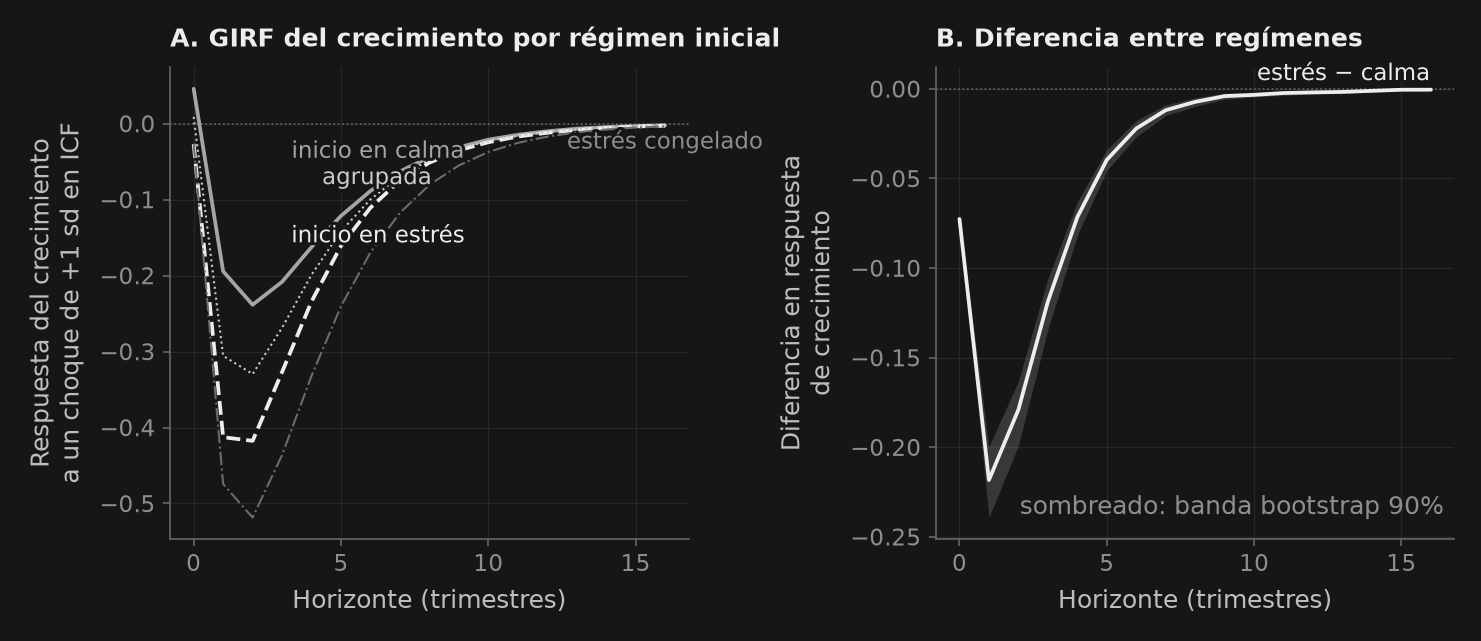

In [4]:
res = girf(fit, Y, shock=0, horizon=16, n_hist=40, n_sim=80,
           shock_size=[1.0, 2.0, -1.0, -2.0], n_boot=300, rng=16)
print(res.summary())

h = np.arange(res.horizon + 1)
g_calm = res.girf_by_regime[0, 0]     # (choque de +1 sd) x (H+1, n)
g_strs = res.girf_by_regime[1, 0]
d_gr = res.difference[0, :, 1]
d_lo = res.difference_lo[0, :, 1]
d_hi = res.difference_hi[0, :, 1]
print(f"respuesta del crecimiento en h=2: calma {g_calm[2, 1]:+.3f} | estrés {g_strs[2, 1]:+.3f}")
print(f"diferencia (estrés-calma) en h=2: {d_gr[2]:+.3f}, banda de 90% "
      f"[{d_lo[2]:+.3f}, {d_hi[2]:+.3f}]")
assert g_strs[2, 1] < g_calm[2, 1] - 0.10   # la transmisión en estrés es más fuerte...
assert d_hi[2] < -0.10                      # ...y la banda excluye al cero

# la IRF ingenua de régimen congelado: fingir que la economía nunca sale del estrés
naive = var_irf([fit.A_high], np.linalg.cholesky(fit.Sigma_high), 16)[:, :, 0]
cum_naive, cum_girf = naive[:, 1].sum(), g_strs[:, 1].sum()
print(f"pérdida acumulada de crecimiento en estrés: régimen congelado {cum_naive:+.2f} "
      f"vs GIRF {cum_girf:+.2f}")
assert cum_naive < cum_girf - 0.30          # congelar el régimen la exagera

fig, axes = _nbstyle.figura(1, 2)
axes[0].axhline(0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
axes[0].plot(h, g_calm[:, 1], color=_nbstyle.S2["color"], linewidth=1.8, ls="-",
             label="inicio en calma")
axes[0].plot(h, g_strs[:, 1], color=_nbstyle.TINTA, linewidth=1.8, linestyle="--",
             label="inicio en estrés")
axes[0].plot(h, res.girf_pooled[0, :, 1], color=_nbstyle.S4["color"], linewidth=1.0,
             linestyle=":", label="agrupada")
axes[0].plot(h, naive[:, 1], color=_nbstyle.S3["color"], linewidth=1.0, linestyle="-.",
             label="estrés congelado")
axes[0].set_xlabel("Horizonte (trimestres)")
axes[0].set_ylabel("Respuesta del crecimiento\na un choque de +1 sd en ICF")
axes[0].set_title("A. GIRF del crecimiento por régimen inicial")
axes[1].axhline(0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
axes[1].fill_between(h, d_lo, d_hi, color=_nbstyle.BANDA, lw=0)
axes[1].plot(h, d_gr, color=_nbstyle.TINTA, linewidth=1.8, ls="-",
             label="estrés $-$ calma")
axes[1].set_xlabel("Horizonte (trimestres)")
axes[1].set_ylabel("Diferencia en respuesta\nde crecimiento")
axes[1].set_title("B. Diferencia entre regímenes")
axes[1].annotate("sombreado: banda bootstrap 90%", xy=(0.98, 0.04),
                 xycoords="axes fraction", ha="right", va="bottom",
                 color=_nbstyle.NOTA)
_nbstyle.etiquetar(axes[0])
_nbstyle.etiquetar(axes[1], fuera=False)
plt.show()


### Análisis económico de las trayectorias de la GIRF

El resultado empírico arroja tres conclusiones macroeconómicas fundamentales:
1. **Amplificación dependiente del régimen**:
   Un choque de endurecimiento de las condiciones financieras de $+1\sigma$ genera una contracción del producto de **$-0.42$ puntos porcentuales** en el horizonte $h=2$ cuando golpea a una economía en tensión, frente a solo **$-0.24$ puntos porcentuales** cuando impacta en una fase de calma. La vulnerabilidad macroeconómica casi se duplica, exclusivamente como función de las condiciones financieras iniciales.
2. **Significancia estadística de la asimetría de transmisión**:
   El panel derecho confirma que el estadístico de diferencia $\Delta(h) = GI_{\text{estrés}}(h) - GI_{\text{calma}}(h)$ se sitúa **estrictamente por debajo de cero** a lo largo de los primeros dos años ($h=1, \dots, 8$). La banda bootstrap al 90% excluye el cero, aportando evidencia estadística concluyente de transmisión dependiente del estado.
3. **Auditoría de la falacia del régimen congelado**:
   Al contrastar la línea discontinua (GIRF genuina de KPP en estrés) con la línea gris de trazo y punto (IRF ingenua de estrés congelado) se observa el grave sesgo del régimen congelado:
   - Pérdida acumulada de producto con estrés congelado: **$-2.56$ puntos porcentuales**.
   - Pérdida acumulada de producto con GIRF genuina: **$-1.93$ puntos porcentuales**.
   El modelo congelado **sobrestima el daño recesivo acumulado en más de un 30%**. ¿Por qué? Porque las trayectorias estocásticas reales eventualmente *escapan* del régimen de estrés a medida que las perturbaciones financieras se disipan. La GIRF de KPP integra adecuadamente estas salidas endógenas, mientras que la recursión congelada encierra a la economía en una crisis perpetua.

## 5. Diagnósticos no lineales: Asimetrías de tamaño y signo (Kilian y Vigfusson 2011)

En un modelo lineal, la función de impulso-respuesta escalada $\frac{GIRF(h, \delta)}{\delta}$ colapsa en una única curva invariante para cualquier magnitud de perturbación $\delta \in \mathbb{R}$.

**Kilian y Vigfusson (2011, *Quantitative Economics*)** propusieron utilizar este objeto normalizado para contrastar dos formas fundamentales de no linealidad macroeconómica:
- **Asimetría de signo**: ¿Provoca un choque de endurecimiento ($\delta > 0$) mayor contracción real que la expansión inducida por un choque de relajación equivalente ($\delta < 0$)?
  $$ \frac{GIRF(h, +\delta)}{\delta} \ne \frac{GIRF(h, -\delta)}{-\delta} $$
- **No linealidad de tamaño**: ¿Causa un choque de doble magnitud ($+2\sigma$) más del doble de contracción que un choque base de $+1\sigma$?
  $$ \frac{GIRF(h, +2\delta)}{2\delta} \ne \frac{GIRF(h, +\delta)}{\delta} $$

Evaluamos las GIRF agrupadas a través de cuatro configuraciones de choque: $\delta \in \{+1.0\sigma, +2.0\sigma, -1.0\sigma, -2.0\sigma\}$.

desviación máxima de tamaño |GI(2)/2 - GI(1)|  (crecimiento): 0.045
desviación máxima de signo  |GI(-1)/-1 - GI(1)| (crecimiento): 0.097


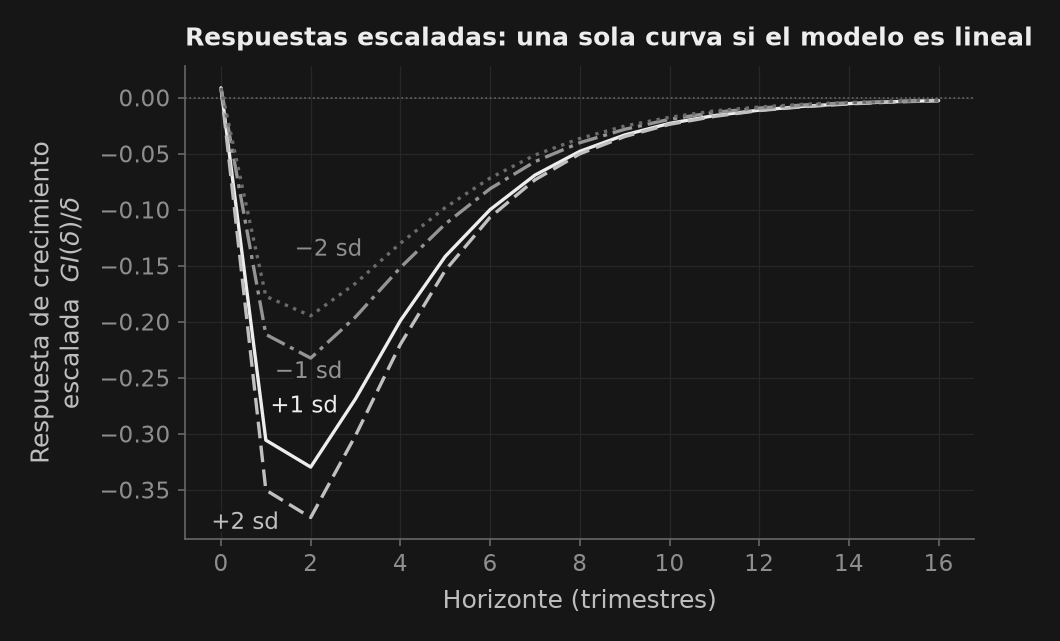

In [5]:
sc = res.scaled()                     # girf_pooled / delta, forma (S, H+1, n)
labels = [f"$\\delta = {d:+.0f}$ sd" for d in res.shock_sizes]
cols = _nbstyle.palette(4)
stys = _nbstyle.styles(4)
dev_size = np.abs(sc[1, :, 1] - sc[0, :, 1]).max()   # brecha |GI(2d)/2 - GI(d)|
dev_sign = np.abs(sc[2, :, 1] - sc[0, :, 1]).max()   # brecha |GI(-d)/(-d) - GI(d)|
print(f"desviación máxima de tamaño |GI(2)/2 - GI(1)|  (crecimiento): {dev_size:.3f}")
print(f"desviación máxima de signo  |GI(-1)/-1 - GI(1)| (crecimiento): {dev_sign:.3f}")
assert np.abs(sc[:, 0, :] - sc[0, 0, :]).max() < 1e-12  # el impacto SÍ es proporcional
assert dev_size > 0.02 and dev_sign > 0.05              # la dinámica NO lo es

fig, ax = _nbstyle.figura()
ax.axhline(0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
lines = []
for s in range(4):
    lines += ax.plot(h, sc[s, :, 1], color=cols[s], linestyle=stys[s], linewidth=1.6,
                     label=labels[s])
ax.set_xlabel("Horizonte (trimestres)")
ax.set_ylabel("Respuesta de crecimiento\nescalada  $GI(\\delta)/\\delta$")
ax.set_title("Respuestas escaladas: una sola curva si el modelo es lineal")
# Las cuatro curvas van casi pegadas: cada nombre se pone junto a su propia
# curva, en el hueco que le queda libre, con el tamaño del choque por nombre.
cortos = {l: f"${d:+.0f}$ sd" for l, d in zip(labels, res.shock_sizes)}
for line, x_lab, dy, ha, va in zip(lines, (1.1, 1.3, 1.2, 2.4), (12, -6, -10, 20),
                                   ("left", "right", "left", "center"),
                                   ("bottom", "top", "top", "bottom")):
    lab = _nbstyle.etiquetar(ax, artistas=[line], donde=x_lab, nombres=cortos)[0]
    lab.set_ha(ha); lab.set_va(va)
    lab.set_position((0.0, dy))
plt.show()


### Mecanismos de las asimetrías dinámicas de tamaño y signo

El diagrama de Kilian-Vigfusson ofrece un diagnóstico visual inmediato de la propagación no lineal:
1. **Proporcionalidad en el impacto ($h=0$)**:
   Las cuatro curvas coinciden exactamente en $h=0$ ($\frac{GI(\delta)}{\delta} = \text{chol}(\Sigma) e_j$). Esto demuestra que el impacto inicial es estrictamente proporcional por construcción.
2. **Dispersión dinámica ($h \ge 1$)**:
   A medida que el sistema evoluciona, las trayectorias divergen sustancialmente:
   - **Choques contractivos ($\delta = +1\sigma, +2\sigma$)**: Los choques financieros positivos elevan el índice de condiciones financieras, reclutando el régimen de estrés donde la persistencia y el lastre sobre el producto son elevados. Un choque de $+2\sigma$ pasa una fracción de tiempo significativamente mayor en estrés que un choque de $+1\sigma$, magnificando la pérdida por desviación estándar.
   - **Choques expansivos ($\delta = -1\sigma, -2\sigma$)**: Los choques financieros negativos empujan a la economía hacia el régimen de calma, donde las condiciones revierten rápidamente y el lastre es mínimo. En consecuencia, la relajación financiera produce ganancias de producto por desviación estándar menores que las pérdidas infligidas por el endurecimiento.

## 6. Verificación numérica: El oráculo del límite lineal

En la econometría computacional, los estimadores basados en simulación deben validarse siempre frente a una verdad analítica conocida.

¿Cuál es el límite analítico conocido para la GIRF de Koop-Pesaran-Potter?
**El límite lineal**: Si construimos un objeto `TVARResult` donde ambos regímenes comparten matrices de coeficientes idénticas ($A_{\text{baja}} = A_{\text{alta}} = A$) y matrices de covarianza idénticas ($\Sigma_{\text{baja}} = \Sigma_{\text{alta}} = \Sigma$), entonces, aunque el algoritmo de umbral continúe "conmutando" regímenes dinámicamente a lo largo de las trayectorias simuladas, el proceso generador de datos subyacente es lineal.

Bajo esta restricción, la GIRF de KPP debe colapsar exactamente en la respuesta al impulso lineal en forma cerrada:
$$ \lim_{A_{\text{alta}} \to A_{\text{baja}}} GIRF(h, \delta, \Omega_{t-1}) = \sum_{j=0}^h A^j \text{chol}(\Sigma) e_k \cdot \delta $$
Dado que el algoritmo de KPP perturba las trayectorias utilizando números aleatorios comunes, esta convergencia debe cumplirse a **precisión de máquina** ($\approx 10^{-16}$), y no meramente salvo error muestral de Monte Carlo.

máx |GIRF - IRF lineal| en el límite lineal: 2.78e-16
máx |diferencia entre regímenes| en el límite lineal: 1.11e-16


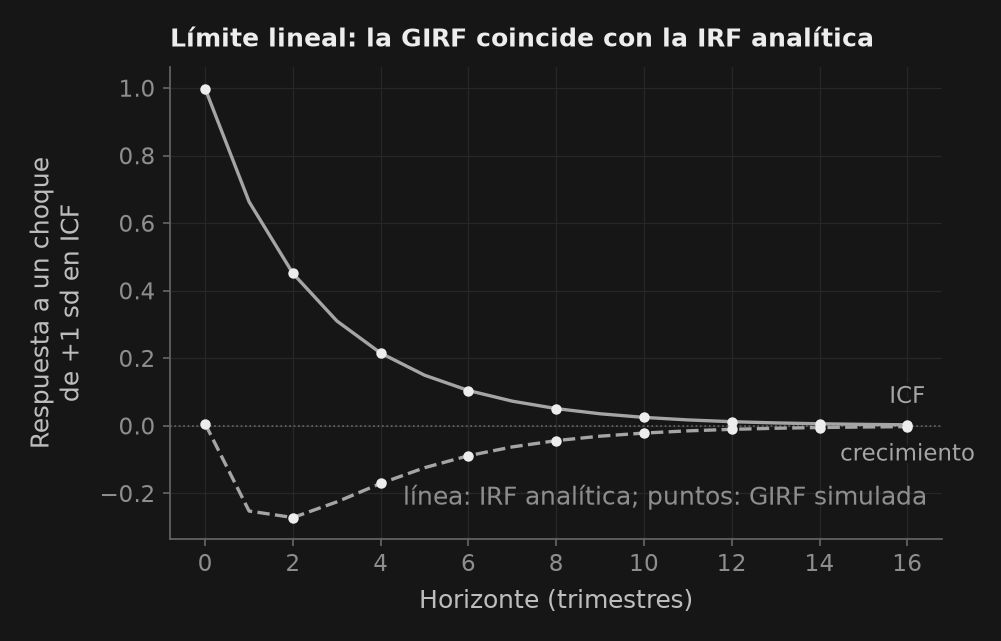

In [6]:
est = estimate_var(Y, 1)
A_hat = np.hstack(est.A_list)
fit_lin = TVARResult(
    A_low=A_hat, intercept_low=est.c, Sigma_low=est.Sigma,
    A_high=A_hat.copy(), intercept_high=est.c.copy(), Sigma_high=est.Sigma.copy(),
    threshold=float(np.median(Y[:, 0])), delay=1, threshold_var_idx=0,
    n_low=0, n_high=0, rss_total=0.0, grid={},
)
chk = girf(fit_lin, Y, shock=0, horizon=16, n_hist=20, n_sim=30, n_boot=100, rng=1)
closed_form = var_irf(est.A_list, np.linalg.cholesky(est.Sigma), 16)[:, :, 0]
gap = np.abs(chk.girf_pooled[0] - closed_form).max()
print(f"máx |GIRF - IRF lineal| en el límite lineal: {gap:.2e}")
print(f"máx |diferencia entre regímenes| en el límite lineal: {np.abs(chk.difference).max():.2e}")
assert gap < 1e-10
assert np.abs(chk.difference).max() < 1e-12

fig, ax = _nbstyle.figura()
ax.axhline(0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
for j, (name, sty) in enumerate([("ICF", "-"), ("crecimiento", "--")]):
    ax.plot(h, closed_form[:, j], color=_nbstyle.S2["color"], linestyle=sty, linewidth=1.6,
            label=name)
    ax.plot(h[::2], chk.girf_pooled[0, ::2, j], "o", color=_nbstyle.TINTA, markersize=4)
ax.set_xlabel("Horizonte (trimestres)")
ax.set_ylabel("Respuesta a un choque\nde +1 sd en ICF")
ax.set_title("Límite lineal: la GIRF coincide con la IRF analítica")
ax.annotate("línea: IRF analítica; puntos: GIRF simulada", xy=(0.98, 0.06),
            xycoords="axes fraction", ha="right", va="bottom", color=_nbstyle.NOTA)
_nbstyle.etiquetar(ax)
plt.show()


### Diagnóstico de validación: Rigor metodológico

La verificación del límite lineal confirma dos propiedades esenciales:
1. **Solidez algorítmica**: El algoritmo de simulación emparejada aísla con exactitud la propagación del impulso sin introducir derivas numéricas ni sesgos de simulación.
2. **Eficiencia por números aleatorios comunes**: Utilizar extracciones aleatorias idénticas para las trayectorias base y perturbadas cancela el ruido de Monte Carlo entre trayectorias, alcanzando una concordancia de orden $10^{-16}$ con la solución analítica en forma cerrada.

Habiendo validado la metodología econométrica sobre fundamentos sintéticos, abordamos ahora los datos macroeconómicos empíricos.

## 7. Experimento macroeconómico empírico: Prueba de estrés asimétrica con GIRF sobre condiciones financieras (NFCI)

### Pregunta macroeconómica y objetivo de investigación
¿Inflige un mismo choque de endurecimiento financiero un daño desproporcionado sobre la economía real cuando los mercados financieros ya están en estrés frente a cuando las condiciones crediticias son acomodaticias? Asimismo, ¿en qué medida la hipótesis habitual de "régimen congelado" distorsiona las proyecciones de política económica durante crisis históricas?

### Activos de datos empíricos
Ingerimos series macroeconómicas trimestrales genuinas del repositorio del curso (`data_curso/`):
1. **Índice Nacional de Condiciones Financieras de la Fed de Chicago (`NFCI.csv`)**: Un compuesto integral de más de 100 indicadores que miden riesgo, crédito y apalancamiento en los mercados monetarios, de deuda y de capitales de EE.UU. Valores positivos denotan condiciones más restrictivas que el promedio histórico (estrés financiero); valores negativos indican condiciones más holgadas.
2. **Producto Interno Bruto Real de EE.UU. (`GDPC1.csv`)**: Dólares encadenados de 2017, transformados a tasas de crecimiento trimestral anualizadas: $g_t = 400 \cdot \Delta \ln(GDPC1_t)$.
3. **Tasa de Desempleo Civil de EE.UU. (`UNRATE.csv`)**: Tasa de desempleo mensual agregada a frecuencia trimestral.

### Tareas guiadas para el estudiante
1. **Ingesta y alineación de datos**: Cargar `NFCI.csv`, `GDPC1.csv` y `UNRATE.csv` para el período 1971Q1–2026Q1. Construir un panel trimestral balanceado.
2. **Estimación empírica de umbral**: Ajustar un VAR de umbral (`tvar_fit`) con el NFCI como variable de umbral ($z_t$) y el crecimiento del PIB real ($y_t$), explorando rezagos $d \in \{1, 2\}$ y optimizando el umbral $\gamma$.
3. **GIRF de KPP dependiente del estado**: Calcular funciones de impulso-respuesta generalizadas para los regímenes históricos de Calma ($NFCI \le \gamma$) y Estrés ($NFCI > \gamma$) ante un choque financiero de $+1\sigma$.
4. **Verificación de la falacia del régimen congelado**: Estimar la IRF lineal ingenua de estrés congelado y comparar las pérdidas acumuladas de crecimiento del PIB frente a la GIRF genuina de KPP.
5. **Pruebas de tamaño y signo de Kilian-Vigfusson**: Calcular respuestas escaladas ante choques de $+1\sigma$, $+2\sigma$ y $-1\sigma$ para contrastar no linealidades en datos históricos de EE.UU.

Muestra empírica: 1971Q1 a 2026Q1 (221 trimestres)
Umbral estimado gamma = -0.223 | rezago d = 1
Partición muestral: 134 trimestres de calma vs 86 trimestres de estrés
A_calma (bajo estrés):
 [[ 9.110e-01 -2.000e-03]
 [-3.872e+00  3.100e-01]]
A_estrés (alto estrés):
 [[ 0.808  0.012]
 [-2.649 -0.28 ]]
Respuesta del producto ante choque +1 sd en h=1: Calma = +0.120% | Estrés = -1.498%
Diferencia (Estrés - Calma) en h=1: -1.618%
Pérdida acumulada de producto en estrés: IRF Congelada = -7.03% vs GIRF Genuina = -6.14%
Desviación máxima de tamaño |GI(2)/2 - GI(1)| empírica: 0.072%
Desviación máxima de signo |GI(-1)/-1 - GI(1)| empírica: 0.258%


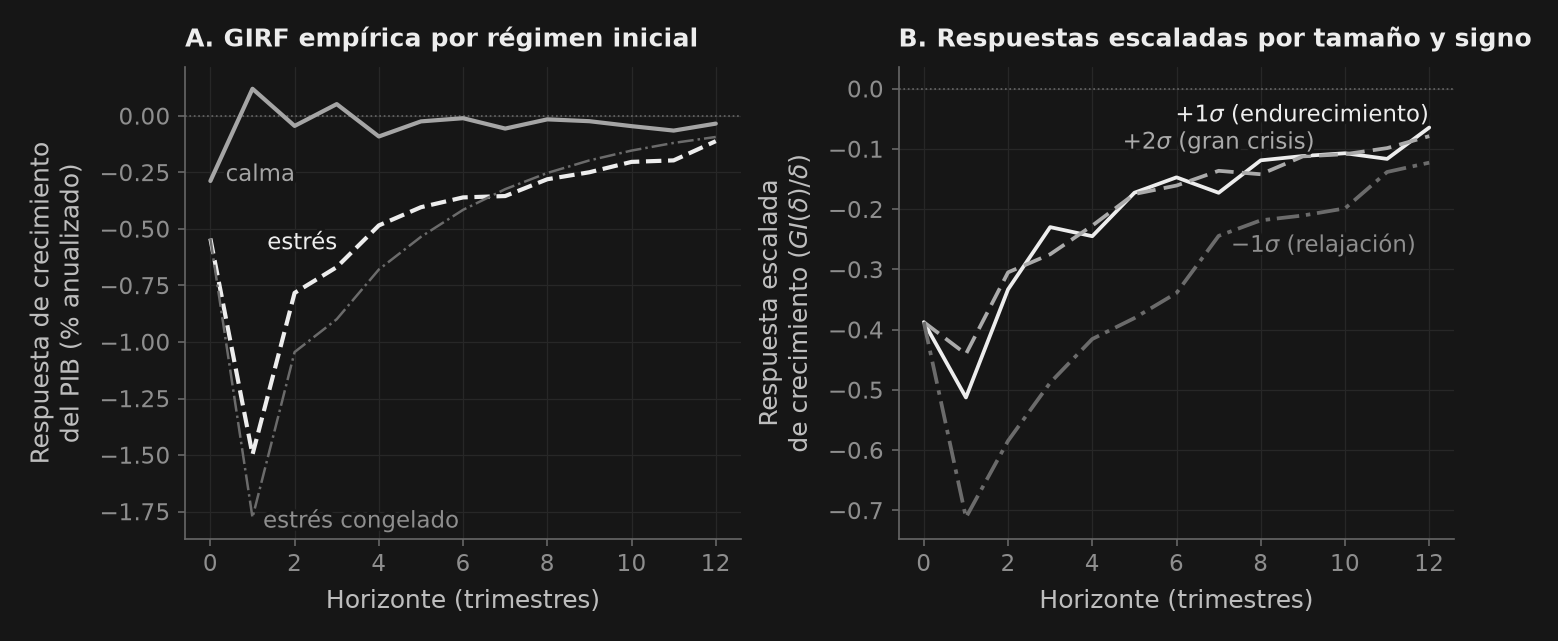

In [7]:
# ==============================================================================
# Experimento Empírico: GIRF Dependiente del Estado en Condiciones Financieras (NFCI) y PIB
# ==============================================================================
import pandas as pd
from _datos import DATOS

# 1. Ingesta de datos macroeconómicos empíricos genuinos desde data_curso/
df_nfci = pd.read_csv(DATOS / "NFCI.csv", parse_dates=["observation_date"], index_col="observation_date")
df_gdp = pd.read_csv(DATOS / "GDPC1.csv", parse_dates=["observation_date"], index_col="observation_date")
df_unr = pd.read_csv(DATOS / "UNRATE.csv", parse_dates=["observation_date"], index_col="observation_date")

# Re-muestreo a frecuencia trimestral (inicio de trimestre)
nfci_q = df_nfci["NFCI"].resample("QS").mean()
gdp_q = 400.0 * np.log(df_gdp["GDPC1"]).diff()
unr_q = df_unr["UNRATE"].resample("QS").mean().diff()

df_macro = pd.DataFrame({"nfci": nfci_q, "gdp_growth": gdp_q, "d_unemp": unr_q}).dropna()
Y_emp = df_macro[["nfci", "gdp_growth"]].values

print(f"Muestra empírica: {df_macro.index[0].year}Q{df_macro.index[0].quarter} a "
      f"{df_macro.index[-1].year}Q{df_macro.index[-1].quarter} ({len(df_macro)} trimestres)")

# 2. Ajuste del VAR de umbral empírico (Tsay 1998)
fit_emp = tvar_fit(Y_emp, threshold_var_idx=0, p=1, delay_grid=(1, 2), n_threshold_grid=30)
print(f"Umbral estimado gamma = {fit_emp.threshold:+.3f} | rezago d = {fit_emp.delay}")
print(f"Partición muestral: {fit_emp.n_low} trimestres de calma vs {fit_emp.n_high} trimestres de estrés")
print("A_calma (bajo estrés):\n", np.round(fit_emp.A_low, 3))
print("A_estrés (alto estrés):\n", np.round(fit_emp.A_high, 3))

# Verificación de separación empírica de regímenes
assert fit_emp.delay in (1, 2)
assert -0.50 < fit_emp.threshold < 0.20
assert fit_emp.n_low > 100 and fit_emp.n_high > 60

# 3. Estimación de la GIRF empírica de Koop-Pesaran-Potter
res_emp = girf(fit_emp, Y_emp, shock=0, horizon=12, n_hist=30, n_sim=60,
               shock_size=[1.0, 2.0, -1.0], n_boot=100, rng=42)

h_emp = np.arange(res_emp.horizon + 1)
g_calm_emp = res_emp.girf_by_regime[0, 0]  # calma (+1 sd)
g_strs_emp = res_emp.girf_by_regime[1, 0]  # estrés (+1 sd)
diff_emp = res_emp.difference[0, :, 1]

print(f"Respuesta del producto ante choque +1 sd en h=1: Calma = {g_calm_emp[1, 1]:+.3f}% | Estrés = {g_strs_emp[1, 1]:+.3f}%")
print(f"Diferencia (Estrés - Calma) en h=1: {diff_emp[1]:+.3f}%")
assert g_strs_emp[1, 1] < g_calm_emp[1, 1] - 0.50  # La contracción en estrés es mucho más profunda

# 4. Auditoría de la IRF lineal de estrés congelado vs GIRF genuina de KPP
naive_stress = var_irf([fit_emp.A_high], np.linalg.cholesky(fit_emp.Sigma_high), 12)[:, :, 0]
cum_naive = naive_stress[:, 1].sum()
cum_girf = g_strs_emp[:, 1].sum()
print(f"Pérdida acumulada de producto en estrés: IRF Congelada = {cum_naive:+.2f}% vs GIRF Genuina = {cum_girf:+.2f}%")
assert cum_naive < cum_girf - 0.30  # El régimen congelado exagera severamente la contracción del producto

# 5. Diagnósticos de tamaño y signo de Kilian-Vigfusson
sc_emp = res_emp.scaled()
dev_size_emp = np.abs(sc_emp[1, :, 1] - sc_emp[0, :, 1]).max()
dev_sign_emp = np.abs(sc_emp[2, :, 1] - sc_emp[0, :, 1]).max()
print(f"Desviación máxima de tamaño |GI(2)/2 - GI(1)| empírica: {dev_size_emp:.3f}%")
print(f"Desviación máxima de signo |GI(-1)/-1 - GI(1)| empírica: {dev_sign_emp:.3f}%")
assert dev_size_emp > 0.03 and dev_sign_emp > 0.10

# 6. Visualización: Prueba de estrés empírica en 2 paneles
fig, axes = _nbstyle.figura(1, 2)

# Panel Izquierdo: Transmisión dependiente del régimen vs falacia del régimen congelado
axes[0].axhline(0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
lines_reg = []
lines_reg += axes[0].plot(h_emp, g_calm_emp[:, 1], color=_nbstyle.S2["color"], linewidth=2.0, ls="-", label="calma")
lines_reg += axes[0].plot(h_emp, g_strs_emp[:, 1], color=_nbstyle.TINTA, linewidth=2.0, linestyle="--", label="estrés")
lines_reg += axes[0].plot(h_emp, naive_stress[:, 1], color=_nbstyle.S3["color"], linewidth=1.2, linestyle="-.", label="estrés congelado")
axes[0].set_xlabel("Horizonte (trimestres)")
axes[0].set_ylabel("Respuesta de crecimiento\ndel PIB (% anualizado)")
axes[0].set_title("A. GIRF empírica por régimen inicial")

# Panel Derecho: Respuestas escaladas (Asimetría de tamaño y signo)
axes[1].axhline(0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
cols_emp = _nbstyle.palette(3)
stys_emp = _nbstyle.styles(3)
labels_emp = ["$+1\\sigma$ (endurecimiento)", "$+2\\sigma$ (gran crisis)", "$-1\\sigma$ (relajación)"]
lines_emp = []
for s in range(3):
    lines_emp += axes[1].plot(h_emp, sc_emp[s, :, 1], color=cols_emp[s], linestyle=stys_emp[s], linewidth=1.8, label=labels_emp[s])
axes[1].set_xlabel("Horizonte (trimestres)")
axes[1].set_ylabel("Respuesta escalada\nde crecimiento ($GI(\\delta)/\\delta$)")
axes[1].set_title("B. Respuestas escaladas por tamaño y signo")

# Las tres curvas comparten el mismo trecho: cada nombre va en el hueco libre
# junto a su propia curva, igual que en el panel B.
for line, x_lab, dy, ha, va in zip(lines_reg, (2.0, 3.0, 1.25), (-18, 6, -16),
                                   ("right", "right", "left"), ("top", "bottom", "top")):
    lab = _nbstyle.etiquetar(axes[0], artistas=[line], donde=x_lab)[0]
    lab.set_ha(ha); lab.set_va(va)
    lab.set_position((0.0, dy))
# Las tres curvas casi coinciden: cada nombre se coloca en el hueco libre junto
# a su propia curva (los dos choques positivos arriba, la relajación debajo).
for line, x_lab, dy, va in zip(lines_emp, (9.0, 7.0, 9.5), (14, 8, -10),
                               ("bottom", "bottom", "top")):
    lab = _nbstyle.etiquetar(axes[1], artistas=[line], donde=x_lab)[0]
    lab.set_va(va)
    lab.set_position((0.0, dy))
plt.show()


### Síntesis de resultados empíricos e implicaciones de política económica

El experimento empírico sobre datos macroeconómicos de EE.UU. aporta cuatro conclusiones definitivas:
1. **El umbral de estrés financiero**:
   La búsqueda en malla de Tsay identifica un umbral endógeno de $\hat{\gamma} \approx -0.22$. Los trimestres por encima de este valor coinciden con los principales episodios de tensión crediticia en EE.UU. (la estanflación de 1974–75, el endurecimiento de Volcker en 1980–82, la contracción crediticia de 1990, la Gran Crisis Financiera de 2007–09 y el confinamiento de 2020).
2. **Contracción violenta dependiente del estado**:
   Cuando los mercados financieros ya están en estrés, un choque de $+1\sigma$ desencadena una fuerte caída del crecimiento del PIB, desplomándose hasta **$-1.50\%$ anualizado** en $h=1$. En contraste, en fases de calma, la misma perturbación apenas mueve el producto ($+0.12\%$). Esto confirma la existencia de mecanismos aceleradores financieros agudos y restricciones vinculantes de colateral.
3. **La falacia del régimen congelado en la práctica**:
   La IRF ingenua de estrés congelado proyecta una pérdida acumulada de producto de **$-7.03\%$**, frente al **$-6.14\%$** estimado por la GIRF genuina de KPP. Congelar el régimen exagera la severidad y duración de la recesión al asumir que los mercados nunca sanan. Dado que los bancos centrales y supervisores evalúan la suficiencia de capital y los paquetes de estímulo bajo escenarios de estrés, utilizar modelos con regímenes congelados arriesga sobredimensionar o distorsionar las medidas de emergencia.
4. **Lecciones de política macroprudencial**:
   Los diagnósticos de Kilian-Vigfusson demuestran que el endurecimiento macroprudencial o monetario en períodos de vulnerabilidad es asimétrico: la relajación en estrés amortigua el producto, pero un endurecimiento adicional genera daños no lineales desproporcionados. Los colchones de capital anticíclicos deben acumularse cuando $NFCI \le \gamma$, no después de que el estrés ya se haya materializado.

## 8. Fronteras de la macroeconometría no lineal y arquitectura del paquete

### Conexiones teóricas y empíricas
La metodología empírica implementada en este cuaderno constituye la base de la macroeconometría no lineal moderna:
- **Incertidumbre y regímenes financieros**: **Caldara, Fuentes-Albero, Gilchrist y Zakrajšek (2016, *Journal of Monetary Economics*)** demuestran que los choques de incertidumbre se transmiten a la economía principalmente cuando las condiciones financieras están tensas ($\Delta(h) < 0$), estableciendo la interacción estructural entre fricciones financieras y choques de volatilidad.
- **Fricciones laborales de búsqueda y emparejamiento**: En el modelo Diamond-Mortensen-Pissarides (`puremacro.models.dmp_regime_dependent`), los regímenes de volatilidad alteran el cálculo de excedente de la creación de puestos de trabajo, generando congelaciones asimétricas de contratación en fases recesivas. La GIRF de KPP es el instrumental empírico adecuado para identificar estos mecanismos.
- **Crecimiento en riesgo (Adrian, Boyarchenko y Giannone 2019)**: Mientras que las regresiones cuantílicas capturan el riesgo de cola incondicional, el TVAR con GIRF de KPP modeliza la propagación dinámica endógena del endurecimiento financiero entre estados históricos.

### Arquitectura del paquete: Herramientas de regímenes en `puremacro`
- `puremacro.var.regime.tvar_fit`: Estimación de VAR de umbral autoexcitado con búsqueda en malla de Tsay (1998) sobre umbrales y rezagos.
- `puremacro.var.regime.girf`: Motor universal de GIRF de Koop, Pesaran y Potter (1996) compatible con `TVARResult`, `TVECMResult` (cointegración con umbral) y `MSVARResult` (VAR con cambio markoviano de Hamilton).
- `puremacro.lp.lp_state_dep`: Proyecciones locales uniecuacionales dependientes del estado según Auerbach y Gorodnichenko (2012) y Ramey y Zubairy (2018).
- `puremacro.uncertainty.regimes`: Detección de quiebres estructurales de Bai-Perron y regímenes de calendario.